Base network (p=0): L(0)=62.9379, C(0)=0.6429
Processing p=0.0010 (1/20)
Processing p=0.0379 (11/20)


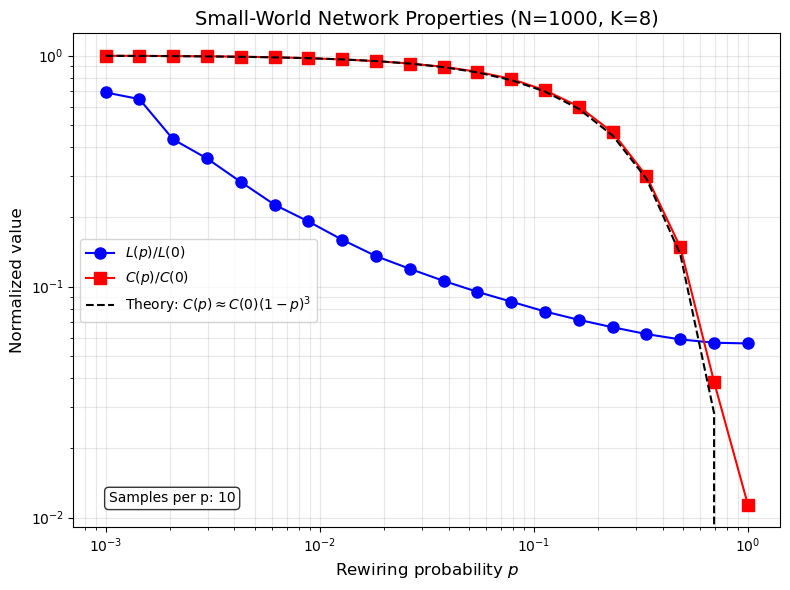

Completed in 88.4 seconds
Small-world behavior observed where:
- High clustering (C(p)/C(0) > 0.5) occurs for p < 0.1624
- Short path lengths (L(p)/L(0) < 0.2) occur for p > 0.0089


: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import time

# Parameters
N, K = 1000, 8  # Network size and degree (must be even)
trials = 10     # Number of samples to average for each p
p_values = np.logspace(-3, 0, 20)  # Rewiring probability from 0.001 to 1.0
ws = nx.watts_strogatz_graph

# Initialize arrays for normalized results
L_norm = np.zeros(len(p_values))
C_norm = np.zeros(len(p_values))

# First create base network (p=0) to get L(0) and C(0)
base_net = ws(N, K, 0, seed=3042)
L0 = nx.average_shortest_path_length(base_net)
C0 = nx.average_clustering(base_net)
print(f"Base network (p=0): L(0)={L0:.4f}, C(0)={C0:.4f}")

# Process each rewiring probability
start_time = time.time()
for i, p in enumerate(p_values):
    # Print progress every 10 iterations
    if i % 10 == 0:
        print(f"Processing p={p:.4f} ({i+1}/{len(p_values)})")
    
    L_sum, C_sum = 0, 0
    
    for t in range(trials):
        # Generate WS network
        G = ws(N, K, p, seed = 3042+t)
        
        # Handle disconnected graphs by using the giant component
        if not nx.is_connected(G):
            giant = max(nx.connected_components(G), key=len)
            G = G.subgraph(giant).copy()
        
        # Calculate metrics
        L = nx.average_shortest_path_length(G)
        C = nx.average_clustering(G)
        
        L_sum += L
        C_sum += C
    
    # Normalize by base values
    L_norm[i] = (L_sum/trials) / L0
    C_norm[i] = (C_sum/trials) / C0

# Calculate theoretical clustering coefficient
theory_C = 0.75 * (K-2)/(K-1) * (1-p_values)**3 / C0

# Plot results
plt.figure(figsize=(8, 6))
plt.loglog(p_values, L_norm, 'bo-', markersize=8, label=r'$L(p)/L(0)$')
plt.loglog(p_values, C_norm, 'rs-', markersize=8, label=r'$C(p)/C(0)$')
plt.loglog(p_values, theory_C, 'k--', linewidth=1.5, 
           label=r'Theory: $C(p) \approx C(0)(1-p)^3$')

# Chart formatting
plt.xlabel('Rewiring probability $p$', fontsize=12)
plt.ylabel('Normalized value', fontsize=12)
plt.title(f'Small-World Network Properties (N={N}, K={K})', fontsize=14)
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend(loc='best')

# Add annotation about sample size
plt.annotate(f'Samples per p: {trials}', xy=(0.05, 0.05), xycoords='axes fraction',
             fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('small_world_crossover.png', dpi=300)
plt.show()

# Print completion message
print(f"Completed in {time.time() - start_time:.1f} seconds")
print("Small-world behavior observed where:")
print(f"- High clustering (C(p)/C(0) > 0.5) occurs for p < {p_values[np.where(C_norm > 0.5)[0][-1]]:.4f}")
print(f"- Short path lengths (L(p)/L(0) < 0.2) occur for p > {p_values[np.where(L_norm < 0.2)[0][0]]:.4f}")